In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands
import ast
import numpy as np

In [2]:
results = pd.read_csv("simulation_results_20260209_1800.csv")

In [3]:
# nsim = 200
# n = [50, 100, 150, 200]
# k = [3]
# sigma = [0, 0.1, 0.5]
# alpha = [0.05]
# marginals = [stats.norm]
# edge_var = [1, 2]
# method = [RVPermutationTest, LLKRatioTest, QAP]
# npermutations = [500]
# metrics = [ComputeAll()]
# approximation = ["F-distr"]

# setup = [
#     (BernoulliNetwork, MLE_logistic),
#     (GaussianNetwork, MLE_gaussian),
# ]

In [4]:
results["sigma"] = results["args"].apply(
    lambda x: re.search(r"'sigma':\s*(\d+\.?\d*)", x).group(1)
)
results["ComputeAll"] = results["ComputeAll"].apply(
    lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x))
)

In [5]:
results["RelativeFrobeniusNorm_x"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results["RelativeFrobeniusNorm_z"] = results["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)
results["FalseRejection"] = results["ComputeAll"].apply(lambda x: x["FalseRejection"])
results["TrueRejection"] = results["ComputeAll"].apply(lambda x: x["TrueRejection"])
results["Rejection"] = results["ComputeAll"].apply(lambda x: x["Rejection"])

### Defining different aggregations

In [6]:
# based on dgp
results_gaussian = results[(results["dgp"] == "GaussianNetwork")].copy()
results_bernoulli = results[(results["dgp"] == "BernoulliNetwork")].copy()

In [7]:
# based on sigma + dgp
results_null_gaussian = results_gaussian[(results_gaussian["sigma"] == "0")].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["sigma"] == "0.5")].copy()
results_alt_001_gaussian = results_gaussian[
    (results_gaussian["sigma"] == "0.01")
].copy()
results_alt_01_gaussian = results_gaussian[(results_gaussian["sigma"] == "0.1")].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["sigma"] == "0")].copy()
results_alt_05_bernoulli = results_bernoulli[
    (results_bernoulli["sigma"] == "0.5")
].copy()
results_alt_001_bernoulli = results_bernoulli[
    (results_bernoulli["sigma"] == "0.01")
].copy()
results_alt_01_bernoulli = results_bernoulli[
    (results_bernoulli["sigma"] == "0.1")
].copy()

In [8]:
# based on sigma + dgp + marginals
results_null_gaussian_gaus_margins = results_null_gaussian[
    results_null_gaussian["marginals"].str.contains("norm", case=False, na=False)
].copy()

results_alt_05_gaussian_gaus_margins = results_alt_05_gaussian[
    results_alt_05_gaussian["marginals"].str.contains("norm", case=False, na=False)
].copy()

results_alt_001_gaussian_gaus_margins = results_alt_001_gaussian[
    results_alt_001_gaussian["marginals"].str.contains("norm", case=False, na=False)
].copy()

results_alt_01_gaussian_gaus_margins = results_alt_01_gaussian[
    results_alt_01_gaussian["marginals"].str.contains("norm", case=False, na=False)
].copy()

results_null_bernoulli_gaus_margins = results_null_bernoulli[
    results_null_bernoulli["marginals"].str.contains("norm", case=False, na=False)
].copy()

results_alt_05_bernoulli_gaus_margins = results_alt_05_bernoulli[
    results_alt_05_bernoulli["marginals"].str.contains("norm", case=False, na=False)
].copy()

results_alt_001_bernoulli_gaus_margins = results_alt_001_bernoulli[
    results_alt_001_bernoulli["marginals"].str.contains("norm", case=False, na=False)
].copy()

results_alt_01_bernoulli_gaus_margins = results_alt_01_bernoulli[
    results_alt_01_bernoulli["marginals"].str.contains("norm", case=False, na=False)
].copy()

results_null_gaussian_laplace_margins = results_null_gaussian[
    results_null_gaussian["marginals"].str.contains("laplace", case=False, na=False)
].copy()

results_alt_05_gaussian_laplace_margins = results_alt_05_gaussian[
    results_alt_05_gaussian["marginals"].str.contains("laplace", case=False, na=False)
].copy()

results_alt_001_gaussian_laplace_margins = results_alt_001_gaussian[
    results_alt_001_gaussian["marginals"].str.contains("laplace", case=False, na=False)
].copy()

results_alt_01_gaussian_laplace_margins = results_alt_01_gaussian[
    results_alt_01_gaussian["marginals"].str.contains("laplace", case=False, na=False)
].copy()

results_null_bernoulli_laplace_margins = results_null_bernoulli[
    results_null_bernoulli["marginals"].str.contains("laplace", case=False, na=False)
].copy()

results_alt_05_bernoulli_laplace_margins = results_alt_05_bernoulli[
    results_alt_05_bernoulli["marginals"].str.contains("laplace", case=False, na=False)
].copy()

results_alt_01_bernoulli_laplace_margins = results_alt_01_bernoulli[
    results_alt_01_bernoulli["marginals"].str.contains("laplace", case=False, na=False)
].copy()

results_alt_001_bernoulli_laplace_margins = results_alt_001_bernoulli[
    results_alt_001_bernoulli["marginals"].str.contains(
        "laplace", case=False, na=False
    )
].copy()

In [9]:
# based on sigma + dgp + marginals + solver
results_null_gaussian_gaus_margins_gaus_mle = results_null_gaussian_gaus_margins[
    (results_null_gaussian_gaus_margins["solver"] == "MLE_gaussian")
].copy()
results_null_gaussian_laplace_margins_gaus_mle = results_null_gaussian_laplace_margins[
    (results_null_gaussian_laplace_margins["solver"] == "MLE_gaussian")
].copy()

results_null_bernoulli_gaus_margins_logistic_mle = results_null_bernoulli_gaus_margins[
    (results_null_bernoulli_gaus_margins["solver"] == "MLE_logistic")
].copy()
results_null_bernoulli_laplace_margins_logistic_mle = (
    results_null_bernoulli_laplace_margins[
        (results_null_bernoulli_laplace_margins["solver"] == "MLE_logistic")
    ].copy()
)

results_alt_05_gaussian_gaus_margins_gaus_mle = results_alt_05_gaussian_gaus_margins[
    (results_alt_05_gaussian_gaus_margins["solver"] == "MLE_gaussian")
].copy()
results_alt_05_gaussian_laplace_margins_gaus_mle = (
    results_alt_05_gaussian_laplace_margins[
        (results_alt_05_gaussian_laplace_margins["solver"] == "MLE_gaussian")
    ].copy()
)
results_alt_01_gaussian_gaus_margins_gaus_mle = results_alt_01_gaussian_gaus_margins[
    (results_alt_01_gaussian_gaus_margins["solver"] == "MLE_gaussian")
].copy()
results_alt_01_gaussian_laplace_margins_gaus_mle = (
    results_alt_01_gaussian_laplace_margins[
        (results_alt_01_gaussian_laplace_margins["solver"] == "MLE_gaussian")
    ].copy()
)
results_alt_001_gaussian_gaus_margins_gaus_mle = results_alt_001_gaussian_gaus_margins[
    (results_alt_001_gaussian_gaus_margins["solver"] == "MLE_gaussian")
].copy()
results_alt_001_gaussian_laplace_margins_gaus_mle = (
    results_alt_001_gaussian_laplace_margins[
        (results_alt_001_gaussian_laplace_margins["solver"] == "MLE_gaussian")
    ].copy()
)

results_alt_05_bernoulli_gaus_margins_logistic_mle = (
    results_alt_05_bernoulli_gaus_margins[
        (results_alt_05_bernoulli_gaus_margins["solver"] == "MLE_logistic")
    ].copy()
)
results_alt_05_bernoulli_laplace_margins_logistic_mle = (
    results_alt_05_bernoulli_laplace_margins[
        (results_alt_05_bernoulli_laplace_margins["solver"] == "MLE_logistic")
    ].copy()
)
results_alt_01_bernoulli_gaus_margins_logistic_mle = (
    results_alt_01_bernoulli_gaus_margins[
        (results_alt_01_bernoulli_gaus_margins["solver"] == "MLE_logistic")
    ].copy()
)
results_alt_01_bernoulli_laplace_margins_logistic_mle = (
    results_alt_01_bernoulli_laplace_margins[
        (results_alt_01_bernoulli_laplace_margins["solver"] == "MLE_logistic")
    ].copy()
)
results_alt_001_bernoulli_gaus_margins_logistic_mle = (
    results_alt_001_bernoulli_gaus_margins[
        (results_alt_001_bernoulli_gaus_margins["solver"] == "MLE_logistic")
    ].copy()
)
results_alt_001_bernoulli_laplace_margins_logistic_mle = (
    results_alt_001_bernoulli_laplace_margins[
        (results_alt_001_bernoulli_laplace_margins["solver"] == "MLE_logistic")
    ].copy()
)

In [10]:
# based on sigma + method + dgp
results_llk_ratio_null_gaussian = results_gaussian[
    (results_gaussian["method"] == "llkratio") & (results_gaussian["sigma"] == "0")
].copy()
results_llk_ratio_alt_001_gaussian = results_gaussian[
    (results_gaussian["method"] == "llkratio") & (results_gaussian["sigma"] == "0.01")
].copy()
results_llk_ratio_alt_05_gaussian = results_gaussian[
    (results_gaussian["method"] == "llkratio") & (results_gaussian["sigma"] == "0.5")
].copy()
results_llk_ratio_alt_01_gaussian = results_gaussian[
    (results_gaussian["method"] == "llkratio") & (results_gaussian["sigma"] == "0.1")
].copy()

results_rv_null_gaussian = results_gaussian[
    (results_gaussian["method"] == "rvpermutation") & (results_gaussian["sigma"] == "0")
].copy()
results_rv_alt_001_gaussian = results_gaussian[
    (results_gaussian["method"] == "rvpermutation")
    & (results_gaussian["sigma"] == "0.01")
].copy()
results_rv_alt_05_gaussian = results_gaussian[
    (results_gaussian["method"] == "rvpermutation")
    & (results_gaussian["sigma"] == "0.5")
].copy()
results_rv_alt_01_gaussian = results_gaussian[
    (results_gaussian["method"] == "rvpermutation")
    & (results_gaussian["sigma"] == "0.1")
].copy()

results_llk_ratio_null_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "llkratio") & (results_bernoulli["sigma"] == "0")
].copy()
results_llk_ratio_alt_001_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "llkratio") & (results_bernoulli["sigma"] == "0.01")
].copy()
results_llk_ratio_alt_05_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "llkratio") & (results_bernoulli["sigma"] == "0.5")
].copy()
results_llk_ratio_alt_01_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "llkratio") & (results_bernoulli["sigma"] == "0.1")
].copy()

results_rv_null_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "rvpermutation")
    & (results_bernoulli["sigma"] == "0")
].copy()
results_rv_alt_001_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "rvpermutation")
    & (results_bernoulli["sigma"] == "0.01")
].copy()
results_rv_alt_05_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "rvpermutation")
    & (results_bernoulli["sigma"] == "0.5")
].copy()
results_rv_alt_01_bernoulli = results_bernoulli[
    (results_bernoulli["method"] == "rvpermutation")
    & (results_bernoulli["sigma"] == "0.1")
].copy()

## Plots

**Ensure type I error is controlled at 5%**

In [11]:
# for the null extract the false rejection to study type I error
agg_null_gaussian_gaus_margins_gaus_mle = aggregate_results(
    results_null_gaussian_gaus_margins_gaus_mle,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_null_gaussian_laplace_margins_gaus_mle = aggregate_results(
    results_null_gaussian_laplace_margins_gaus_mle,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_null_bernoulli_gaus_margins_logistic_mle = aggregate_results(
    results_null_bernoulli_gaus_margins_logistic_mle,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_null_bernoulli_laplace_margins_logistic_mle = aggregate_results(
    results_null_bernoulli_laplace_margins_logistic_mle,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)

In [12]:
observed = ['CCApermutation_observed', 'RVPermutationTest_observed']

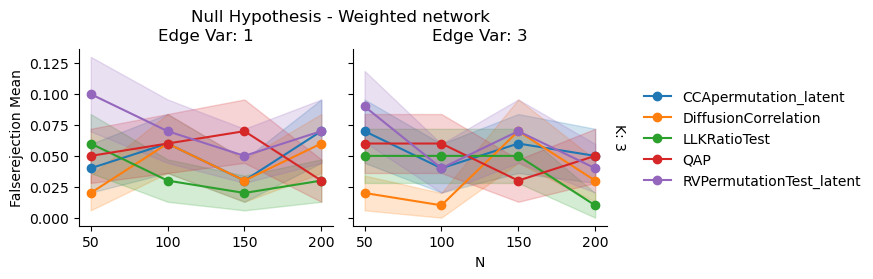

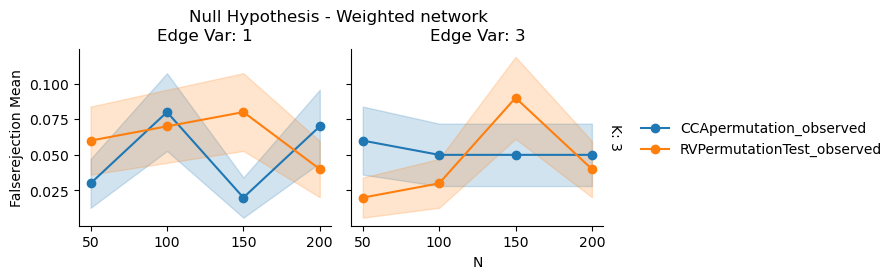

In [13]:
temp = agg_null_gaussian_gaus_margins_gaus_mle.copy()

plot_grid(
    grouped_stats=temp[~temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "edge_var", "k"],
    height=2.5,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Null Hypothesis - Weighted network ",
)

plot_grid(
    grouped_stats=temp[temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "edge_var", "k"],
    height=2.5,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Null Hypothesis - Weighted network ",
)

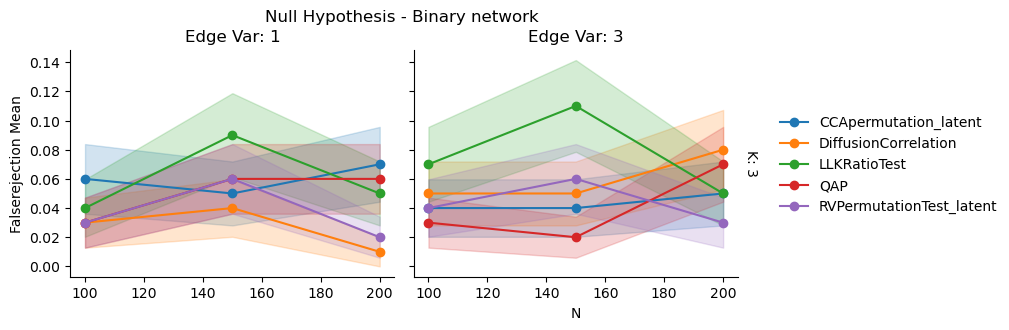

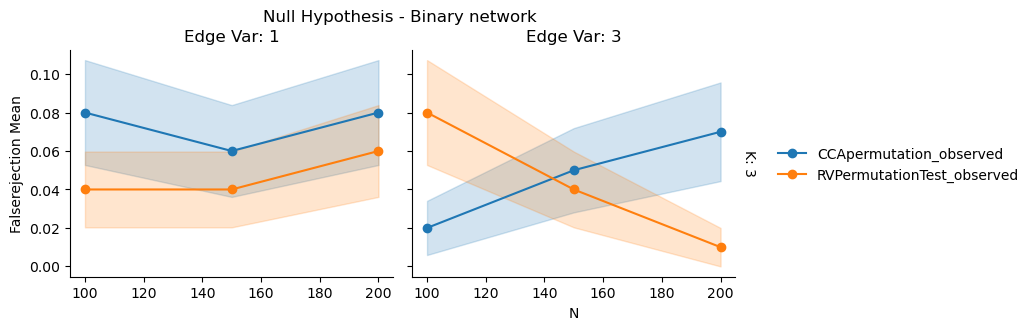

In [14]:
temp = agg_null_bernoulli_gaus_margins_logistic_mle.copy()
temp = temp[temp['n']>=100]

plot_grid(
    grouped_stats=temp[~temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "edge_var", "k"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Null Hypothesis - Binary network ",
)

plot_grid(
    grouped_stats=temp[temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "edge_var", "k"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Null Hypothesis - Binary network ",
)

# Study Power

In [15]:
# based on sigma + dgp + marginals + solver
agg_alt_001_gaussian_gaus_margins_gaus_mle = aggregate_results(
    results_alt_001_gaussian_gaus_margins_gaus_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_001_gaussian_laplace_margins_gaus_mle = aggregate_results(
    results_alt_001_gaussian_laplace_margins_gaus_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_001_bernoulli_gaus_margins_logistic_mle = aggregate_results(
    results_alt_001_bernoulli_gaus_margins_logistic_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_001_bernoulli_laplace_margins_logistic_mle = aggregate_results(
    results_alt_001_bernoulli_laplace_margins_logistic_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)

agg_alt_01_gaussian_gaus_margins_gaus_mle = aggregate_results(
    results_alt_01_gaussian_gaus_margins_gaus_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_01_gaussian_laplace_margins_gaus_mle = aggregate_results(
    results_alt_01_gaussian_laplace_margins_gaus_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_01_bernoulli_gaus_margins_logistic_mle = aggregate_results(
    results_alt_01_bernoulli_gaus_margins_logistic_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_01_bernoulli_laplace_margins_logistic_mle = aggregate_results(
    results_alt_01_bernoulli_laplace_margins_logistic_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)

agg_alt_05_gaussian_gaus_margins_gaus_mle = aggregate_results(
    results_alt_05_gaussian_gaus_margins_gaus_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_05_gaussian_laplace_margins_gaus_mle = aggregate_results(
    results_alt_05_gaussian_laplace_margins_gaus_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_05_bernoulli_gaus_margins_logistic_mle = aggregate_results(
    results_alt_05_bernoulli_gaus_margins_logistic_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)
agg_alt_05_bernoulli_laplace_margins_logistic_mle = aggregate_results(
    results_alt_05_bernoulli_laplace_margins_logistic_mle,
    y_axis="TrueRejection",
    x_axis="n",
    factors=["edge_var", "k", "method"],
)

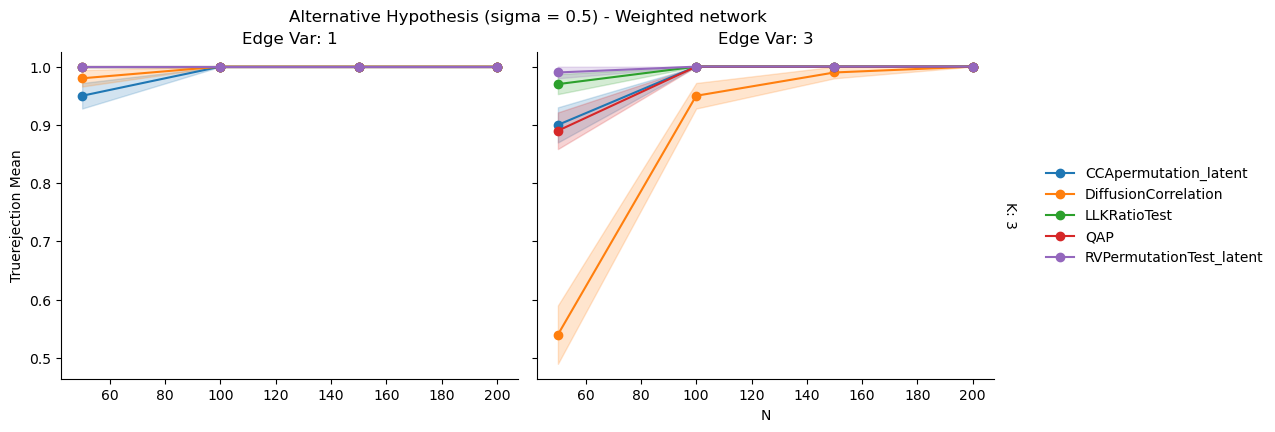

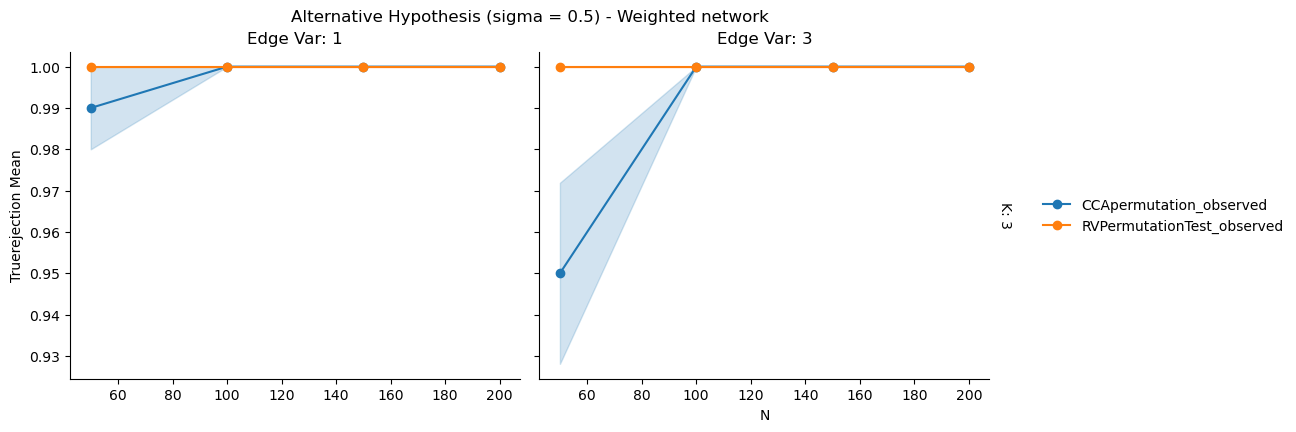

In [16]:
temp = agg_alt_05_gaussian_gaus_margins_gaus_mle.copy()
# sigma 0.5
plot_grid(
    grouped_stats=temp[~temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "edge_var", "k"],
    height=4,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
    title="Alternative Hypothesis (sigma = 0.5) - Weighted network",
)

plot_grid(
    grouped_stats=temp[temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "edge_var", "k"],
    height=4,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
    title="Alternative Hypothesis (sigma = 0.5) - Weighted network",
)

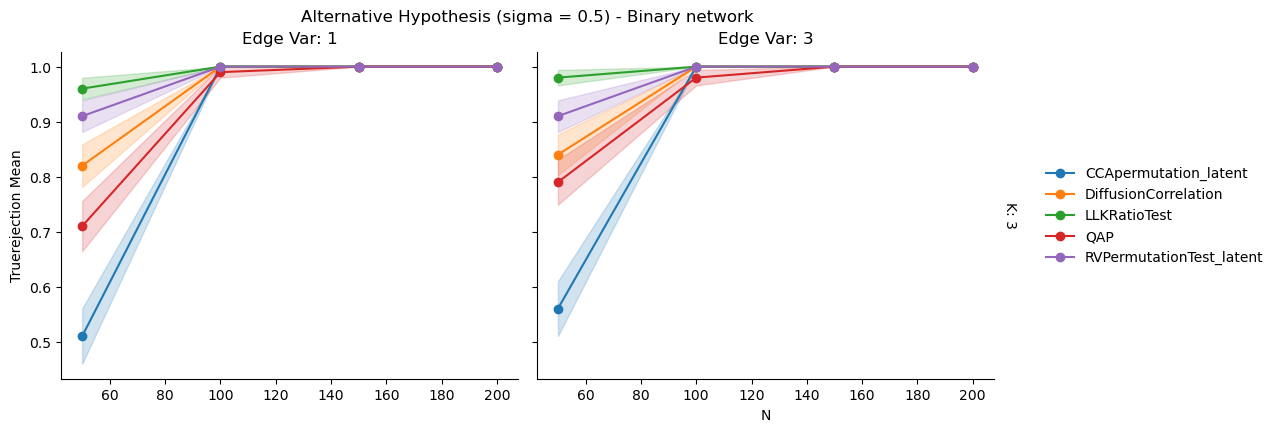

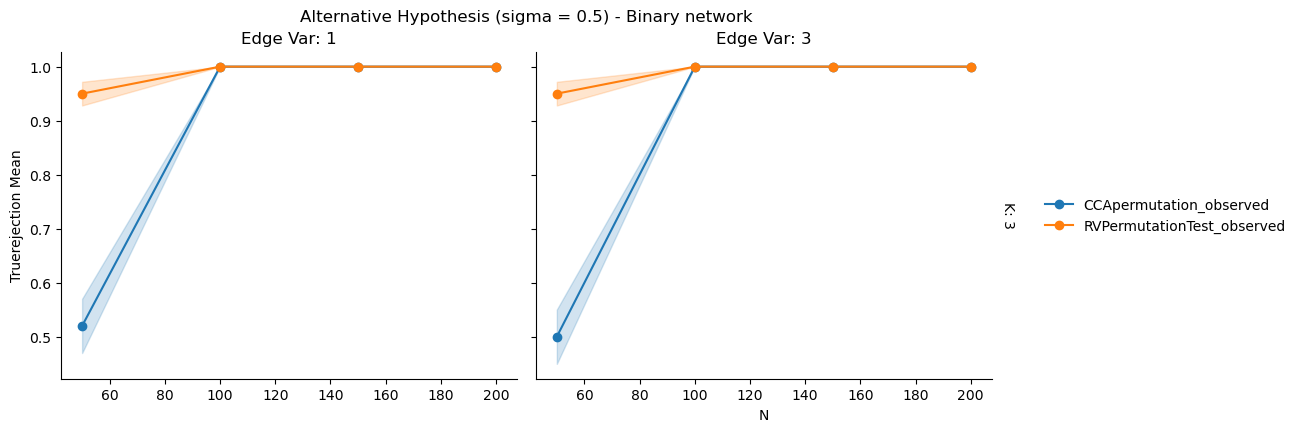

In [17]:
temp = agg_alt_05_bernoulli_gaus_margins_logistic_mle.copy()

plot_grid(
    grouped_stats=temp[~temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "edge_var", "k"],
    height=4,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
    title="Alternative Hypothesis (sigma = 0.5) - Binary network",
)


plot_grid(
    grouped_stats=temp[temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "edge_var", "k"],
    height=4,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=True,
    title="Alternative Hypothesis (sigma = 0.5) - Binary network",
)


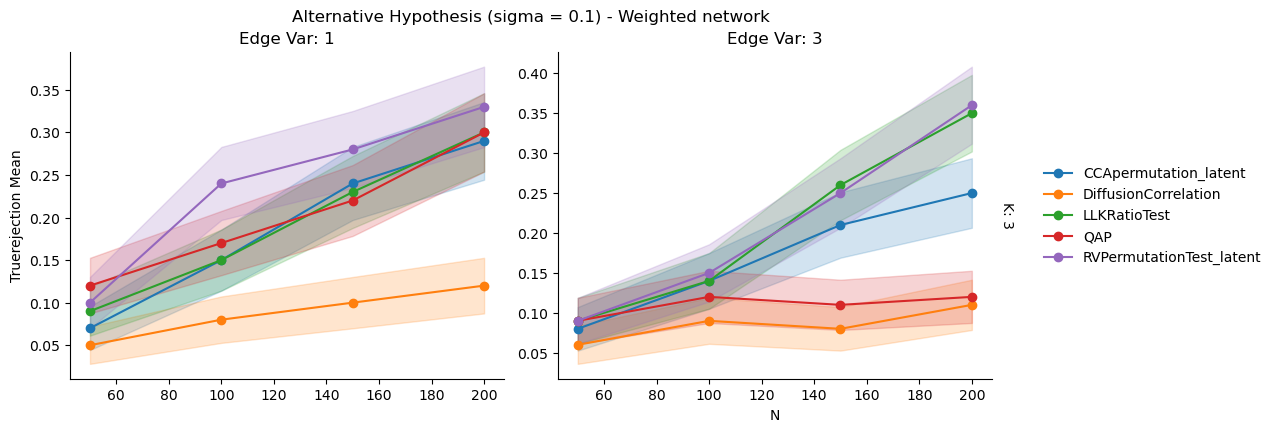

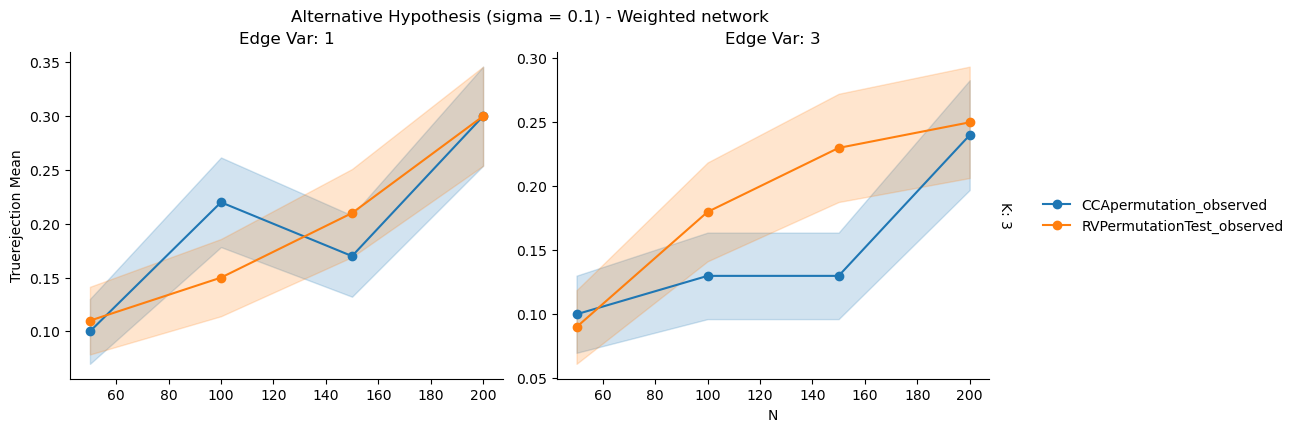

In [18]:
# sigma 0.1
temp = agg_alt_01_gaussian_gaus_margins_gaus_mle.copy()

plot_grid(
    grouped_stats=temp[~temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "edge_var", "k"],
    height=4,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Alternative Hypothesis (sigma = 0.1) - Weighted network",
)


plot_grid(
    grouped_stats=temp[temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "edge_var", "k"],
    height=4,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Alternative Hypothesis (sigma = 0.1) - Weighted network",
)

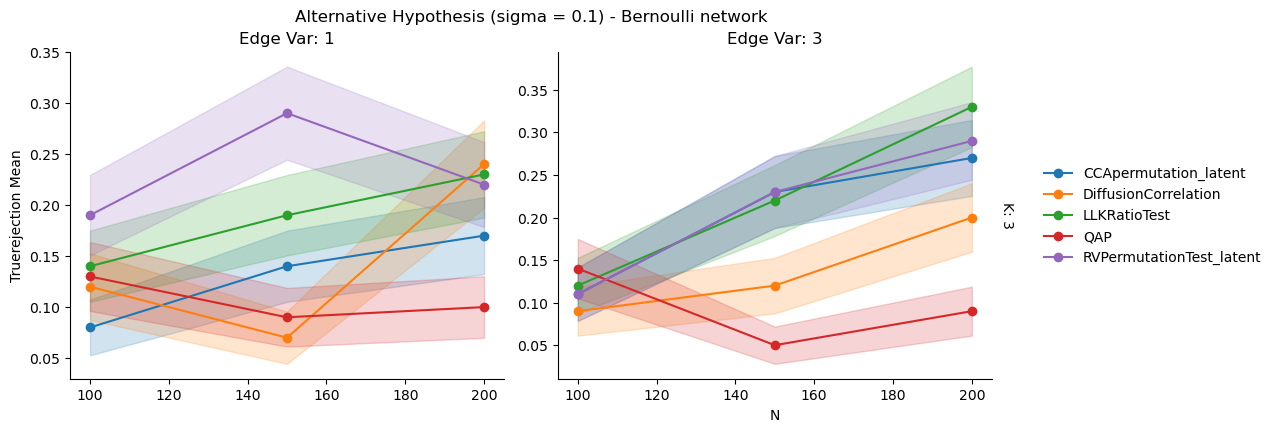

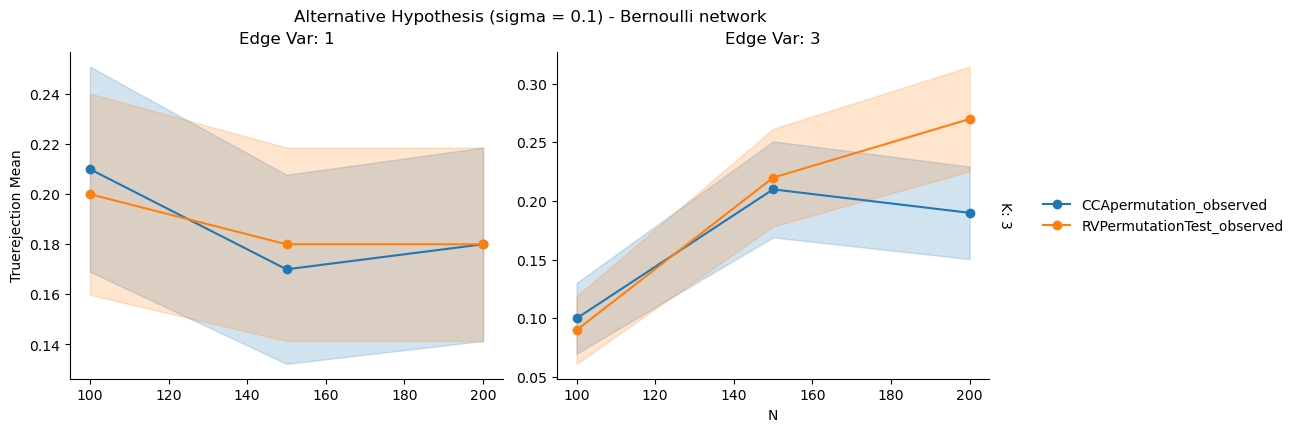

In [19]:
temp = agg_alt_01_bernoulli_gaus_margins_logistic_mle.copy()
temp = temp[temp['n']>=100]

plot_grid(
    grouped_stats=temp[~temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "edge_var", "k"],
    height=4,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Alternative Hypothesis (sigma = 0.1) - Bernoulli network",
)

plot_grid(
    grouped_stats=temp[temp['method'].isin(observed)],
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "edge_var", "k"],
    height=4,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Alternative Hypothesis (sigma = 0.1) - Bernoulli network",
)